In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

📂 Scanning 622 label files in /home/genki/GR/Sign-Segmentation/processed_data/BIO_tags...

📊 DATASET SIGN DISTRIBUTION
Total Files Analyzed : 622
Files WITH Signs     : 574
Files WITHOUT Signs  : 48 (Only 'Outside' frames)


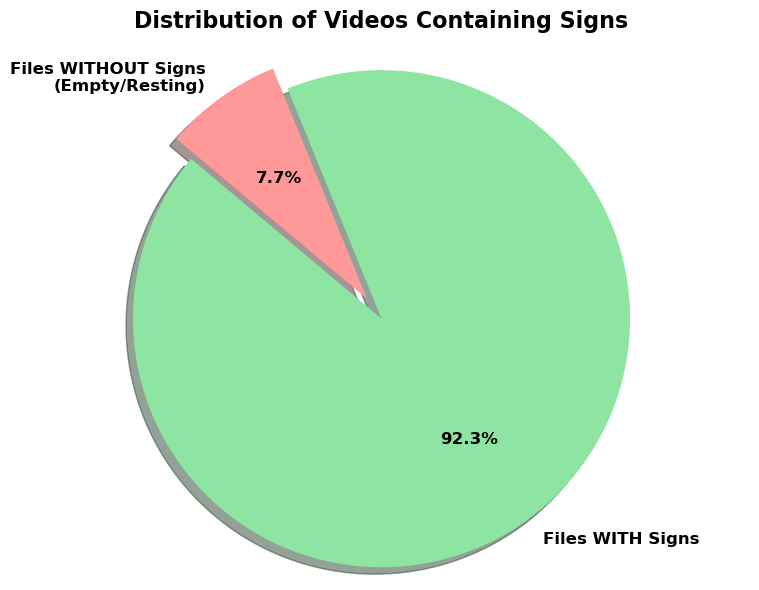

In [2]:
def count_and_plot_empty_signs():
    # Define the target directory
    project_root = Path.cwd()
    
    # Simple check to find the processed_data directory
    for candidate in [project_root, project_root.parent]:
        labels_dir = candidate / "processed_data" / "BIO_tags"
        if labels_dir.exists():
            break
            
    if not labels_dir.exists():
        print(f"❌ Error: Could not find directory {labels_dir}")
        return

    files = list(labels_dir.glob("*.npy"))
    if not files:
        print(f"❌ Error: No .npy files found in {labels_dir}")
        return
        
    print(f"📂 Scanning {len(files)} label files in {labels_dir}...")

    with_signs_count = 0
    without_signs_count = 0
    
    for file_path in files:
        # Load the label array
        labels = np.load(file_path)
        
        # Convert soft labels (T, 3) to hard labels (T,) if necessary
        if labels.ndim > 1:
            hard_labels = np.argmax(labels, axis=1)
        else:
            hard_labels = labels
            
        # BIO classes: 0 = Outside, 1 = Inside, 2 = Begin
        # If the maximum value in the array is 0, there are no signs (no 1s or 2s)
        if np.max(hard_labels) == 0:
            without_signs_count += 1
        else:
            with_signs_count += 1

    # --- Print Summary ---
    print("\n" + "="*40)
    print("📊 DATASET SIGN DISTRIBUTION")
    print("="*40)
    print(f"Total Files Analyzed : {len(files):,}")
    print(f"Files WITH Signs     : {with_signs_count:,}")
    print(f"Files WITHOUT Signs  : {without_signs_count:,} (Only 'Outside' frames)")
    print("="*40)

    # --- Plot Pie Chart ---
    labels = ['Files WITH Signs', 'Files WITHOUT Signs\n(Empty/Resting)']
    sizes = [with_signs_count, without_signs_count]
    colors = ['#8de5a1', '#ff9999'] # Soft green and red
    
    # 'Explode' the empty signs slice slightly to make it stand out
    explode = (0, 0.1) if without_signs_count > 0 else (0, 0)

    plt.figure(figsize=(8, 6))
    plt.pie(sizes, 
            explode=explode, 
            labels=labels, 
            colors=colors, 
            autopct='%1.1f%%',
            shadow=True, 
            startangle=140,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
            
    plt.title('Distribution of Videos Containing Signs', fontsize=16, fontweight='bold', pad=20)
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    count_and_plot_empty_signs()

Using labels directory: /home/genki/GR/Sign-Segmentation/processed_data/BIO_tags
Scanning 622 files to calculate gloss counts...

📊 GLOSS COUNT STATISTICS (Per Video)
Total Videos Analyzed : 622
Overall Average       : 508.70 glosses
99th Percentile Cutoff: 1906 glosses
--------------------------------------------------
✅ Normal Videos      : 615 (<= 1906 glosses)
🚨 Anomaly Videos     : 7 (> 1906 glosses)
   Max Anomaly Count  : 4082 glosses


/tmp/ipykernel_178366/3463550426.py:74: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/genki/miniconda3/envs/sign-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


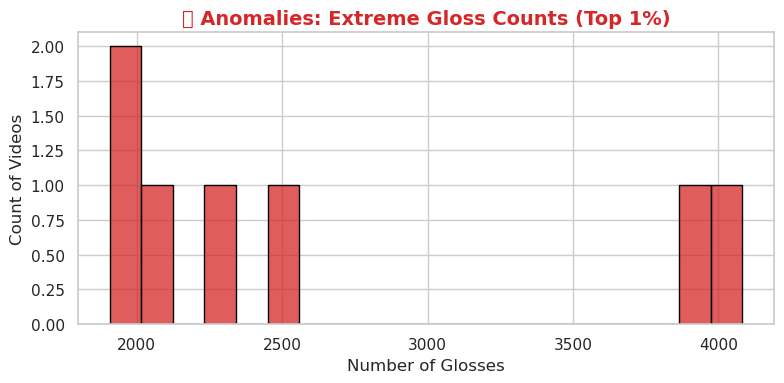

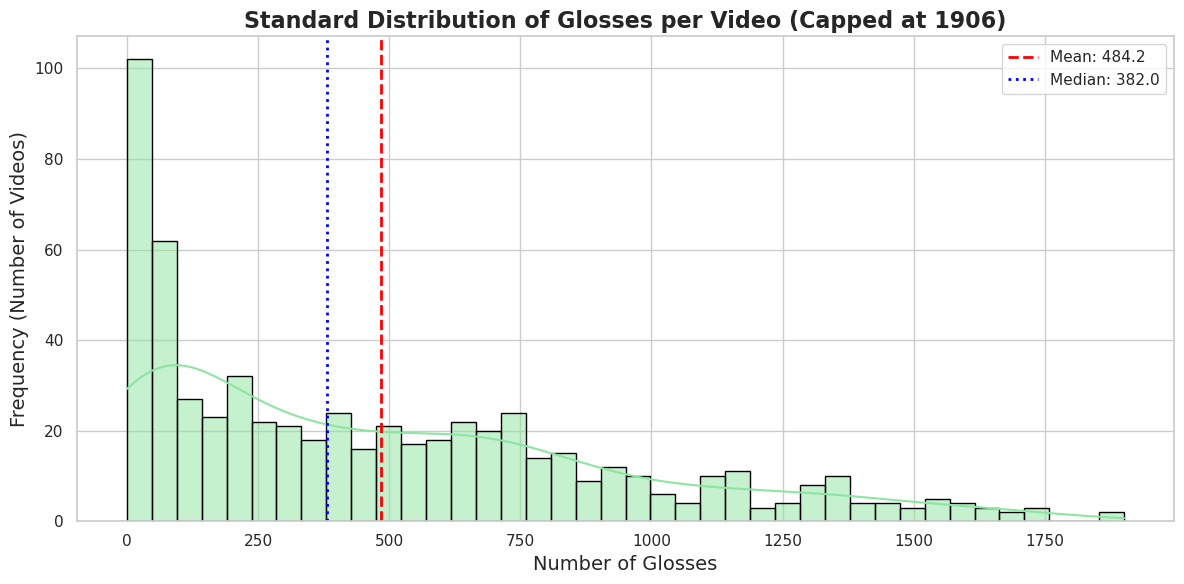

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# Configuration & Setup
# ==========================================
project_root = Path.cwd()
for candidate in [project_root, project_root.parent]:
    labels_dir = candidate / "processed_data" / "BIO_tags"
    if labels_dir.exists():
        break

if not labels_dir.exists():
    print(f"❌ Error: Could not find directory {labels_dir}")
else:
    print(f"Using labels directory: {labels_dir}")
    
    files = [f for f in os.listdir(labels_dir) if f.endswith('.npy')]
    gloss_counts = []
    
    print(f"Scanning {len(files)} files to calculate gloss counts...")
    
    for file_name in files:
        label_path = os.path.join(labels_dir, file_name)
        labels = np.load(label_path)
        
        if labels.ndim > 1:
            hard_labels = np.argmax(labels, axis=1)
        else:
            hard_labels = labels
            
        num_glosses = np.sum(hard_labels == 2)
        gloss_counts.append(num_glosses)
    
    counts_series = pd.Series(gloss_counts)
    
    # ==========================================
    # Anomaly Separation (99th Percentile Rule)
    # ==========================================
    p99 = counts_series.quantile(0.99)
    
    normal_data = counts_series[counts_series <= p99]
    anomaly_data = counts_series[counts_series > p99]
    
    # --- Print Summary Statistics ---
    print("\n" + "="*50)
    print("📊 GLOSS COUNT STATISTICS (Per Video)")
    print("="*50)
    print(f"Total Videos Analyzed : {len(counts_series):,}")
    print(f"Overall Average       : {counts_series.mean():.2f} glosses")
    print(f"99th Percentile Cutoff: {p99:.0f} glosses")
    print("-" * 50)
    print(f"✅ Normal Videos      : {len(normal_data):,} (<= {p99:.0f} glosses)")
    print(f"🚨 Anomaly Videos     : {len(anomaly_data):,} (> {p99:.0f} glosses)")
    if not anomaly_data.empty:
        print(f"   Max Anomaly Count  : {anomaly_data.max()} glosses")
    print("="*50)
    
    sns.set_theme(style="whitegrid")
    
    # ==========================================
    # Plot 1: The Anomalies (Top 1%)
    # ==========================================
    if not anomaly_data.empty:
        plt.figure(figsize=(8, 4))
        sns.histplot(anomaly_data, bins=20, color="#d62728", edgecolor="black")
        plt.title("🚨 Anomalies: Extreme Gloss Counts (Top 1%)", fontsize=14, fontweight='bold', color="#d62728")
        plt.xlabel("Number of Glosses", fontsize=12)
        plt.ylabel("Count of Videos", fontsize=12)
        plt.tight_layout()
        plt.show()  # Display and flush the figure state

    # ==========================================
    # Plot 2: The Main Distribution (Bottom 99%)
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Plot normal data with 40 bins
    sns.histplot(normal_data, bins=40, color="#8de5a1", edgecolor="black", kde=True)
    
    plt.title(f"Standard Distribution of Glosses per Video (Capped at {p99:.0f})", fontsize=16, fontweight='bold')
    plt.xlabel("Number of Glosses", fontsize=14)
    plt.ylabel("Frequency (Number of Videos)", fontsize=14)
    
    # Add vertical lines for the normal distribution mean and median
    plt.axvline(normal_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {normal_data.mean():.1f}')
    plt.axvline(normal_data.median(), color='blue', linestyle=':', linewidth=2, label=f'Median: {normal_data.median():.1f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

Using keypoints directory: /home/genki/GR/Sign-Segmentation/processed_data/keypoints
Scanning 622 keypoint files for zero values...



📊 ZERO VALUE STATISTICS (Per Node)
Total Frames Analyzed : 17,372,807
Total Zeros Found     : 186
Worst Performing Node : Node 11 (20 zero-valued frames)
Highest Zero Rate     : 0.00%


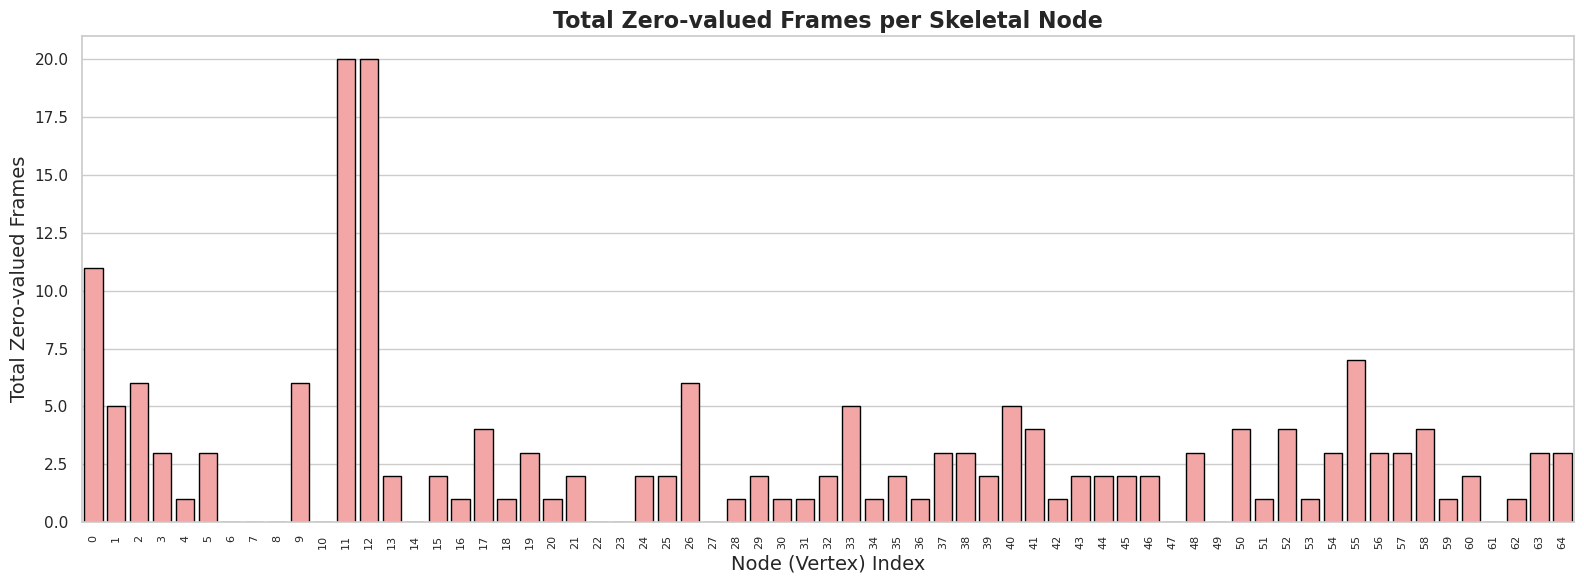


Top 5 Nodes with Most Zero Values:
 Node_Index  Zero_Count  Zero_Rate_%
         11          20     0.000115
         12          20     0.000115
          0          11     0.000063
         55           7     0.000040
          2           6     0.000035


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# Configuration & Setup
# ==========================================
project_root = Path.cwd()
for candidate in [project_root, project_root.parent]:
    keypoints_dir = candidate / "processed_data" / "keypoints"
    if keypoints_dir.exists():
        break

if not keypoints_dir.exists():
    print(f"❌ Error: Could not find directory {keypoints_dir}")
else:
    print(f"Using keypoints directory: {keypoints_dir}")
    
    files = [f for f in os.listdir(keypoints_dir) if f.endswith('.npy')]
    
    total_zero_per_node = None
    total_frames = 0
    
    print(f"Scanning {len(files)} keypoint files for zero values...")
    
    for file_name in files:
        kp_path = os.path.join(keypoints_dir, file_name)
        
        # Load keypoints: Expected shape is (Frames, Vertices, Channels)
        kp_array = np.load(kp_path)
        frames, vertices, channels = kp_array.shape
        total_frames += frames
        
        # Initialize the accumulator array dynamically based on vertex count
        if total_zero_per_node is None:
            total_zero_per_node = np.zeros(vertices, dtype=int)
            
        # Check for zeros. If any channel (x, y, z) is 0, count the node as zero-valued for that frame
        zero_nodes = (kp_array == 0).any(axis=2)
        
        # Sum zero-valued frames per node (down the time axis) and add to our total
        total_zero_per_node += zero_nodes.sum(axis=0)

    # Convert to Pandas DataFrame for easy plotting and sorting
    df_zeros = pd.DataFrame({
        'Node_Index': np.arange(len(total_zero_per_node)),
        'Zero_Count': total_zero_per_node
    })
    
    # Calculate the percentage of frames where each node was zero
    df_zeros['Zero_Rate_%'] = (df_zeros['Zero_Count'] / total_frames) * 100

    # --- Print Summary Statistics ---
    print("\n" + "="*50)
    print("📊 ZERO VALUE STATISTICS (Per Node)")
    print("="*50)
    print(f"Total Frames Analyzed : {total_frames:,}")
    print(f"Total Zeros Found     : {df_zeros['Zero_Count'].sum():,}")
    print(f"Worst Performing Node : Node {df_zeros['Zero_Count'].idxmax()} ({df_zeros['Zero_Count'].max():,} zero-valued frames)")
    print(f"Highest Zero Rate     : {df_zeros['Zero_Rate_%'].max():.2f}%")
    print("="*50)

    # --- Plot the Bar Chart ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))
    
    ax = sns.barplot(
        data=df_zeros, 
        x='Node_Index', 
        y='Zero_Count', 
        color='#ff9999', 
        edgecolor='black'
    )
    
    plt.title("Total Zero-valued Frames per Skeletal Node", fontsize=16, fontweight='bold')
    plt.xlabel("Node (Vertex) Index", fontsize=14)
    plt.ylabel("Total Zero-valued Frames", fontsize=14)
    
    plt.xticks(rotation=90, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Nodes with Most Zero Values:")
    print(df_zeros.sort_values(by='Zero_Count', ascending=False).head(5).to_string(index=False))
